<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Freq: D
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB
None
           Ex_rate
count  7588.000000
mean      0.776974
std       0.136620
min       0.483297
25%       0.701422
50%       0.761377
75%       0.873477
max       1.102536
Ex_rate    0
dtype: int64


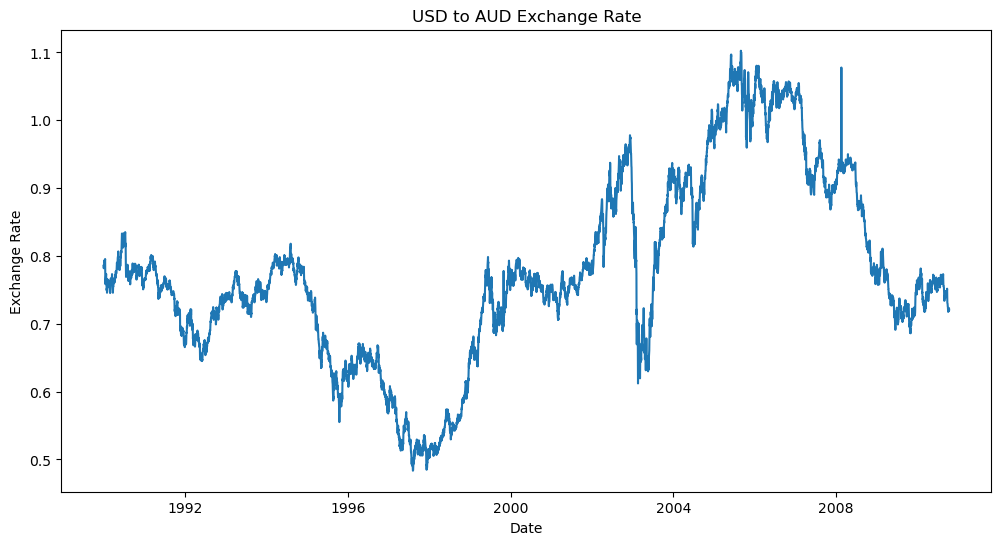

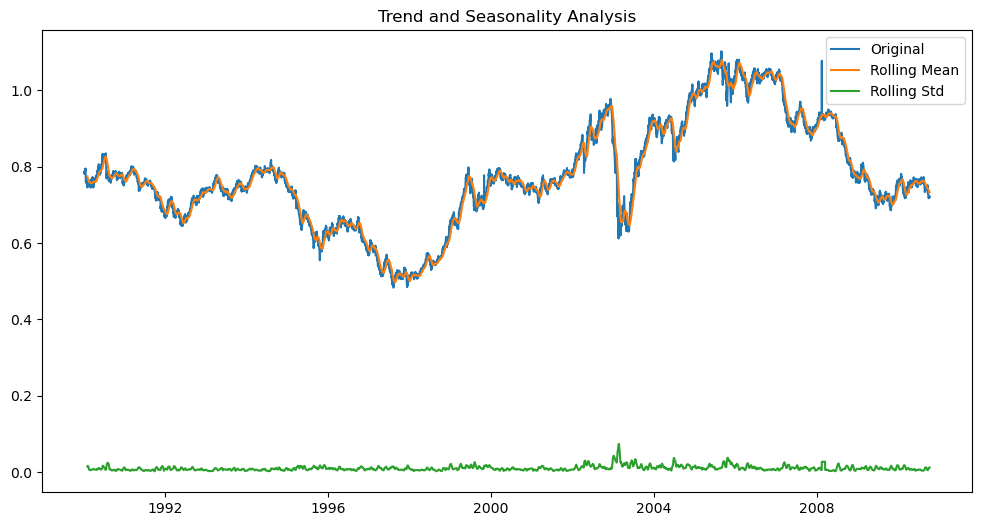

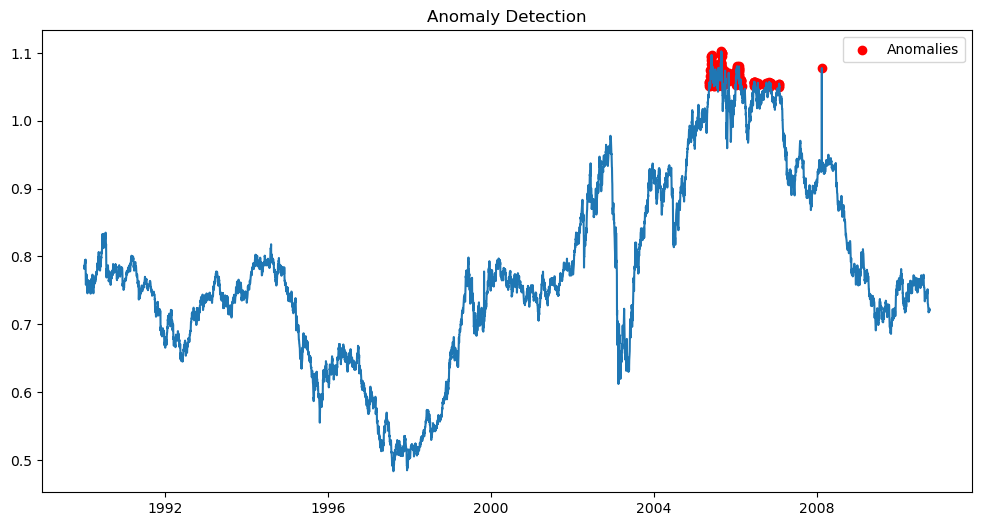

ADF Statistic: -1.6649941807381343
p-value: 0.44923273535979974


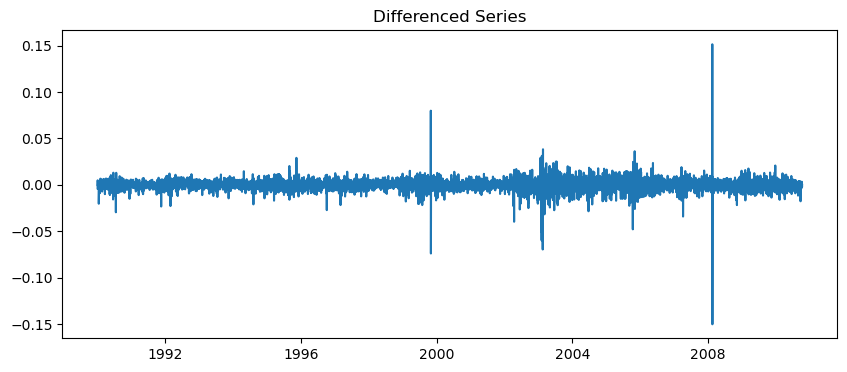

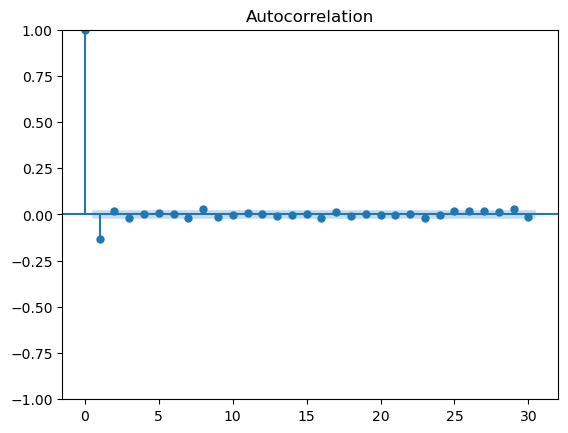

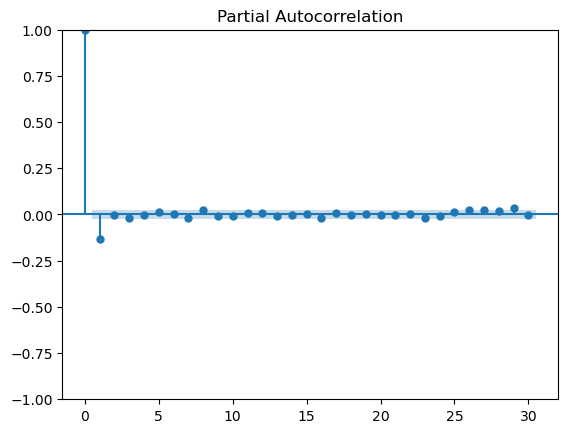

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Best ARIMA Order: (1, 1, 1)
Best AIC: -45432.091583259054
                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Sat, 09 May 2026   AIC                         -45432.092
Time:                        22:45:31   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       

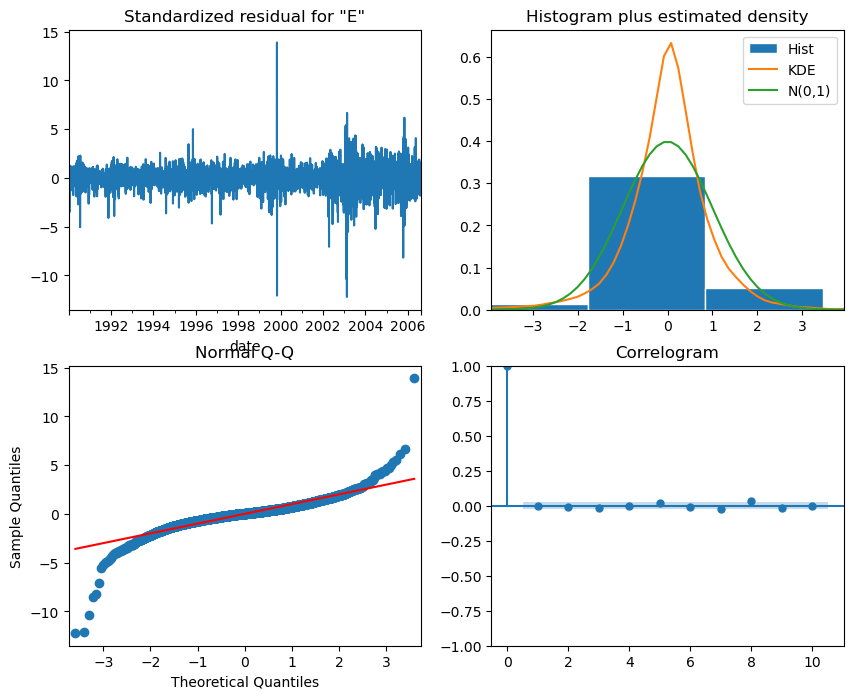

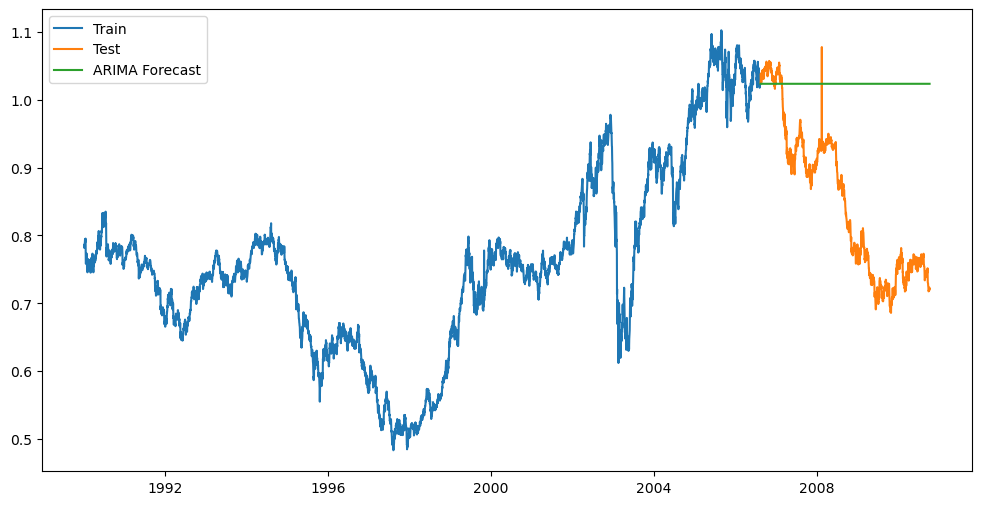

Best ES Trend: mul
Best ES AIC: -62655.49017284614


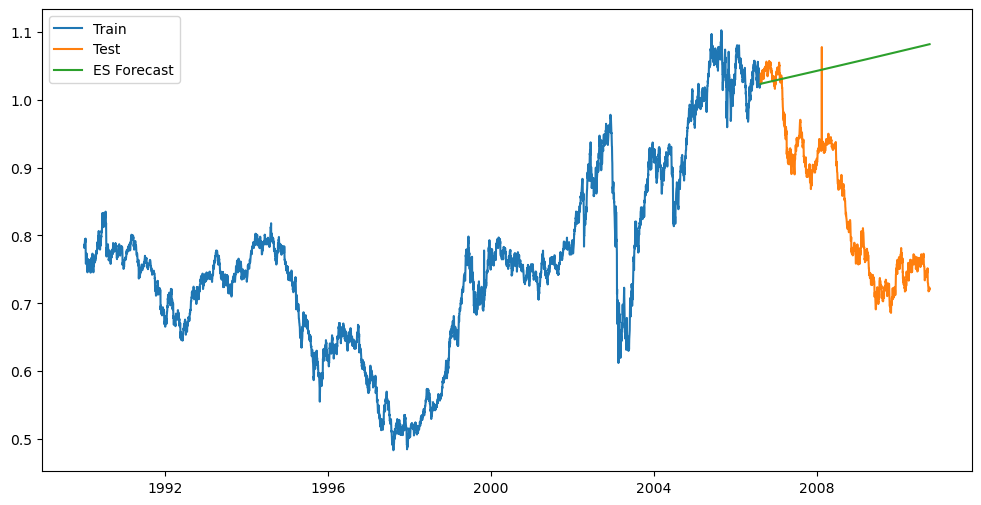

ARIMA -> MAE: 0.17770970449120707 RMSE: 0.20543669659668565 MAPE: 22.79796617381075
ExpSmooth -> MAE: 0.20580211143637522 RMSE: 0.23823154161489016 MAPE: 26.408242517316165


In [2]:
import numpy as np
import pandas as pd

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv(
    r"C:\Users\NIKHIL\Downloads\data science assignment\data science assignment\exchange_rate.csv"
)

# ==========================================
# DATE CONVERSION
# ==========================================

df['date'] = pd.to_datetime(
    df['date'],
    dayfirst=True
)

df.set_index('date', inplace=True)

# Add Frequency
df = df.asfreq('D')

# ==========================================
# DATA OVERVIEW
# ==========================================

print(df.info())

print(df.describe())

print(df.isnull().sum())

# ==========================================
# INITIAL TIME SERIES VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df.iloc[:,0])

plt.title("USD to AUD Exchange Rate")

plt.xlabel("Date")

plt.ylabel("Exchange Rate")

plt.show()

# ==========================================
# HANDLE MISSING VALUES
# ==========================================

df = df.ffill()

# ==========================================
# TREND & SEASONALITY ANALYSIS
# ==========================================

ts = df.iloc[:,0]

rolling_mean = ts.rolling(window=30).mean()

rolling_std = ts.rolling(window=30).std()

plt.figure(figsize=(12,6))

plt.plot(ts, label='Original')

plt.plot(rolling_mean, label='Rolling Mean')

plt.plot(rolling_std, label='Rolling Std')

plt.title("Trend and Seasonality Analysis")

plt.legend()

plt.show()

# ==========================================
# ANOMALY DETECTION
# ==========================================

plt.figure(figsize=(12,6))

plt.plot(ts)

plt.scatter(
    ts[ts > ts.mean() + 2*ts.std()].index,
    ts[ts > ts.mean() + 2*ts.std()],
    color='red',
    label='Anomalies'
)

plt.title("Anomaly Detection")

plt.legend()

plt.show()

# ==========================================
# ADF TEST
# ==========================================

from statsmodels.tsa.stattools import adfuller

result = adfuller(df.iloc[:,0])

print("ADF Statistic:", result[0])

print("p-value:", result[1])

# ==========================================
# DIFFERENCING
# ==========================================

ts_diff = ts.diff().dropna()

plt.figure(figsize=(10,4))

plt.plot(ts_diff)

plt.title("Differenced Series")

plt.show()

# ==========================================
# ACF & PACF
# ==========================================

from statsmodels.graphics.tsaplots import (
    plot_acf,
    plot_pacf
)

plot_acf(ts_diff, lags=30)

plt.show()

plot_pacf(ts_diff, lags=30)

plt.show()

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

train_size = int(len(ts) * 0.8)

train = ts[:train_size]

test = ts[train_size:]

# ==========================================
# ARIMA PARAMETER OPTIMIZATION
# ==========================================

from statsmodels.tsa.arima.model import ARIMA

best_aic = np.inf

best_order = None

for p in range(0,3):

    for d in range(0,2):

        for q in range(0,3):

            try:

                temp_model = ARIMA(
                    train,
                    order=(p,d,q)
                ).fit()

                if temp_model.aic < best_aic:

                    best_aic = temp_model.aic

                    best_order = (p,d,q)

            except:
                continue

print("Best ARIMA Order:", best_order)

print("Best AIC:", best_aic)

# ==========================================
# ARIMA MODEL
# ==========================================

model_arima = ARIMA(
    train,
    order=best_order
)

model_arima_fit = model_arima.fit()

print(model_arima_fit.summary())

# ==========================================
# ARIMA DIAGNOSTICS
# ==========================================

model_arima_fit.plot_diagnostics(
    figsize=(10,8)
)

plt.show()

# ==========================================
# ARIMA FORECAST
# ==========================================

forecast_arima = model_arima_fit.forecast(
    steps=len(test)
)

plt.figure(figsize=(12,6))

plt.plot(train, label='Train')

plt.plot(test, label='Test')

plt.plot(
    test.index,
    forecast_arima,
    label='ARIMA Forecast'
)

plt.legend()

plt.show()

# ==========================================
# EXPONENTIAL SMOOTHING OPTIMIZATION
# ==========================================

from statsmodels.tsa.holtwinters import (
    ExponentialSmoothing
)

trend_types = ['add', 'mul']

best_es_aic = np.inf

best_trend = None

for t in trend_types:

    try:

        temp_es = ExponentialSmoothing(
            train,
            trend=t,
            seasonal=None
        ).fit()

        if temp_es.aic < best_es_aic:

            best_es_aic = temp_es.aic

            best_trend = t

    except:
        continue

print("Best ES Trend:", best_trend)

print("Best ES AIC:", best_es_aic)

# ==========================================
# EXPONENTIAL SMOOTHING MODEL
# ==========================================

model_es = ExponentialSmoothing(
    train,
    trend=best_trend,
    seasonal=None
)

model_es_fit = model_es.fit()

forecast_es = model_es_fit.forecast(
    len(test)
)

# ==========================================
# ES FORECAST VISUALIZATION
# ==========================================

plt.figure(figsize=(12,6))

plt.plot(train, label='Train')

plt.plot(test, label='Test')

plt.plot(
    test.index,
    forecast_es,
    label='ES Forecast'
)

plt.legend()

plt.show()

# ==========================================
# EVALUATION METRICS
# ==========================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

def evaluate(actual, predicted):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    mape = np.mean(
        np.abs(
            (actual - predicted) / actual
        )
    ) * 100

    return mae, rmse, mape

# ==========================================
# ARIMA EVALUATION
# ==========================================

mae_a, rmse_a, mape_a = evaluate(
    test,
    forecast_arima
)

# ==========================================
# ES EVALUATION
# ==========================================

mae_e, rmse_e, mape_e = evaluate(
    test,
    forecast_es
)

# ==========================================
# FINAL RESULTS
# ==========================================

print(
    "ARIMA -> MAE:",
    mae_a,
    "RMSE:",
    rmse_a,
    "MAPE:",
    mape_a
)

print(
    "ExpSmooth -> MAE:",
    mae_e,
    "RMSE:",
    rmse_e,
    "MAPE:",
    mape_e
)

Exchange rate shows non-stationary behavior.
Differencing was required for ARIMA.
ARIMA captured short-term fluctuations better.
Exponential smoothing performed well for trend.
Based on error metrics, (choose lower RMSE model) performed better.
